In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

BASELINE_DIR = os.path.expanduser("~/methylbert_finetune/methylbert/myNotebooks")
sys.path.insert(0, BASELINE_DIR)
from baseline_two_means import load          # reuse the baseline's window loader

HOME       = os.path.expanduser("~")
PRED_DIR   = os.path.join(HOME, "methylbert_finetune/predictions/predictions100")
BASE_TRAIN = os.path.join(HOME, "finetuneDatasets/dmr100/train_seq.csv")
BASE_TEST  = os.path.join(HOME, "finetuneTestdata/dmr100_test/data.csv")
CLASS_NAMES = ["no match (0)", "match (1)"]

In [2]:
def model_cm(seed, wtag):
    df = pd.read_csv(os.path.join(PRED_DIR, f"preds_s{seed}_{wtag}_methylation_test.csv"))
    y    = df["y_oriented"].astype(int).values
    pred = (df["p_oriented"].astype(float).values > 0.5).astype(int)
    return confusion_matrix(y, pred, labels=[0, 1])

def baseline_cm(train_path, eval_path):
    train, ev = load(train_path), load(eval_path)
    train, ev = train.dropna(subset=["m"]), ev.dropna(subset=["m"])
    prof = train.pivot_table(index="dmr_label", columns="ctype", values="m", aggfunc="mean")
    for c in ("T", "N"):
        if c not in prof.columns:
            prof[c] = np.nan
    ev = ev.join(prof.rename(columns={"T": "profT", "N": "profN"}), on="dmr_label")
    is_T = ev["dmr_ctype"].values == "T"
    H  = np.where(is_T, ev["profT"].values, ev["profN"].values)
    Lo = np.where(is_T, ev["profN"].values, ev["profT"].values)
    m  = ev["m"].values
    valid = ~np.isnan(H) & ~np.isnan(Lo)
    score = (np.abs(m - Lo) - np.abs(m - H))[valid]
    label = ((ev["ctype"].values == ev["dmr_ctype"].values).astype(int))[valid]
    return confusion_matrix(label, (score > 0).astype(int), labels=[0, 1])

panels = [
    ("Methylation-aware (seed 42)", model_cm(42, "w")),
    ("Ablation (seed 42)",          model_cm(42, "wo")),
    ("Baseline (two-means)",        baseline_cm(BASE_TRAIN, BASE_TEST)),
]
for name, cm in panels:
    print(name, cm.tolist())
# sanity: the baseline matrix should equal [[11727, 7348], [4383, 11420]]

Methylation-aware (seed 42) [[4791, 47], [115, 4569]]
Ablation (seed 42) [[4781, 57], [111, 4573]]
Baseline (two-means) [[4776, 62], [120, 4564]]


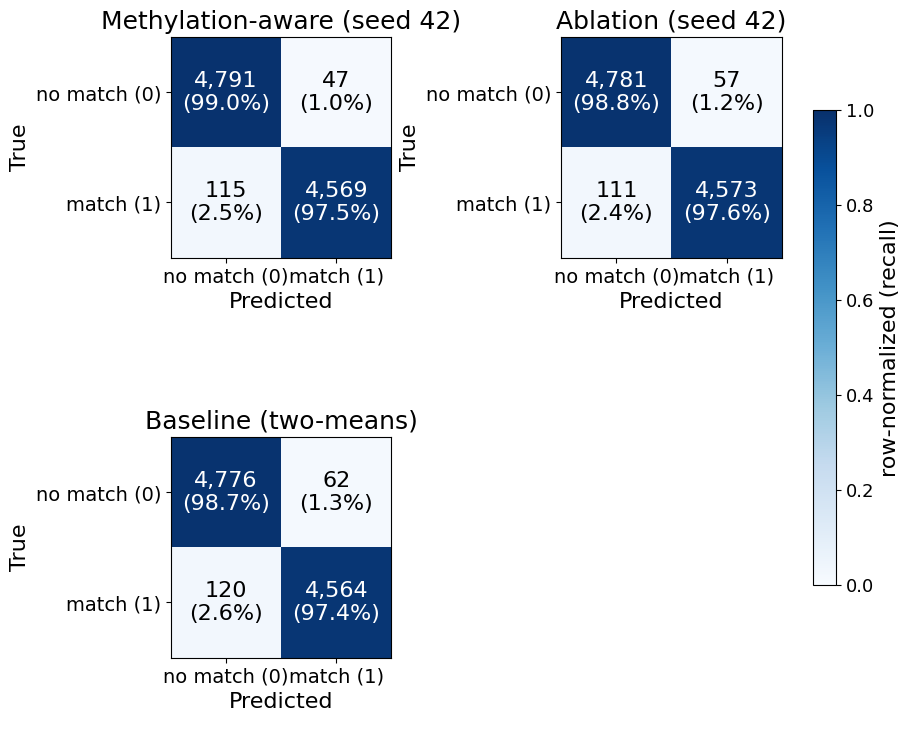

In [3]:
import matplotlib.pyplot as plt

with plt.rc_context({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
}):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
    axes = axes.ravel()
    im = None
    for ax, (name, cm) in zip(axes, panels):
        cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)   # row-normalized = recall
        im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(name)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}\n({cmn[i, j]*100:.1f}%)",
                        ha="center", va="center", fontsize=16,
                        color="white" if cmn[i, j] > 0.5 else "black")
    axes[3].axis("off")                                        # empty fourth tile
    cbar = fig.colorbar(im, ax=axes.tolist(), label="row-normalized (recall)", shrink=0.6)
    cbar.set_label("row-normalized (recall)", fontsize=16)
    cbar.ax.tick_params(labelsize=13)
    fig.savefig("confusion_matrices_dmr100.pdf", bbox_inches="tight")
    plt.show()